# Ghana LEAP 1000 — DiD Estimation

> *Ghana Livelihood Empowerment Against Poverty (LEAP) 1000 Impact Evaluation*  
> Institute of Statistical, Social & Economic Research (ISSER), University of Ghana, Legon.

---

## Programme

**LEAP 1000** is a government cash-transfer programme targeting extremely poor households with children aged 0–1.  Implemented by Ghana's Department of Social Welfare, it provides quarterly transfers to improve household welfare and break intergenerational poverty.

The impact evaluation uses a **cluster-randomised controlled trial (RCT)**:

| Design element | Detail |
|---|---|
| Trial regions | Northern & Upper East Ghana |
| Trial districts | 5 (East Mamprusi, Karaga, Yendi, Bongo, Garu-Tempane) |
| Randomisation unit | Sub-district community / cluster |
| Eligibility | Household has ≥ 1 child aged 0–1 **and** PMT score below the national poverty threshold |
| Waves | Baseline 2015, Endline 2017 |
| Primary outcome | Adult-equivalent household expenditure / month (constant GH₵) |

**Eligibility screening** uses the **Proxy Means Test (PMT)** — a composite welfare index computed from observable household characteristics (housing quality, demographics, asset ownership).  All study households score below the poverty cut-off (PMT range: 7.0–7.3 on an index scale, SD ≈ 0.08), confirming a well-targeted, homogeneous sample.

**Goal of this notebook**: estimate and interpret the DiD effect of LEAP 1000 on household expenditure, and clarify what causal quantity it identifies (ITT vs ATT).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.apps.ghana.data      import load_data, W_ALL, W_LABELS, NUMERIC_W, BINARY_W
from src.apps.ghana.analysis  import naive_did, regression_did, balance_tests
from src.apps.ghana.visualize import plot_ghana_map, plot_love, plot_parallel_trends

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
DATA_DIR = '../data/ghana'
TREAT_COLOR, CTRL_COLOR = '#e07b39', '#5b8db8'

df_full = load_data(DATA_DIR)

# Balanced panel: keep only households observed in both waves
hh_both = df_full.groupby('hhid')['wave'].nunique()
balanced_ids = hh_both[hh_both == 2].index
df = df_full[df_full['hhid'].isin(balanced_ids)].copy()

df0 = df[df['wave'] == 0].copy()   # baseline only
df1 = df[df['wave'] == 1].copy()   # endline only

n_dropped = df_full['hhid'].nunique() - df['hhid'].nunique()
n_base, n_end = len(df0), len(df1)
print(f'Full dataset    : {len(df_full):,} rows  ({df_full["hhid"].nunique():,} households)')
print(f'Dropped         : {n_dropped} households seen in one wave only')
print(f'Balanced panel  : {len(df):,} rows  ({df["hhid"].nunique():,} households)')
print(f'  Baseline      : {n_base:,}  (T={df0["T"].sum():,}  C={n_base - df0["T"].sum():,})')
print(f'  Endline       : {n_end:,}  (T={df1["T"].sum():,}  C={n_end - df1["T"].sum():,})')
print(f'Regions         : {dict(df["region"].value_counts())}')

RESULTS_DIR = Path('../results/ghana')
MAP_DIR = RESULTS_DIR / 'map'
MAP_DIR.mkdir(parents=True, exist_ok=True)

Full dataset    : 4,828 rows  (2,497 households)
Dropped         : 166 households seen in one wave only
Balanced panel  : 4,662 rows  (2,331 households)
  Baseline      : 2,331  (T=1,185  C=1,146)
  Endline       : 2,331  (T=1,185  C=1,146)
Regions         : {'Northern': np.int64(3200), 'Upper East': np.int64(1462)}


## Study area

The trial was conducted across five districts in Ghana's Northern and Upper East regions — among the country's poorest areas.

The dataset contains **162 community identifiers** (`comm`) with GPS centroids (all households in the same community share one coordinate). Crucially, **`comm` is a geographic area marker, not the randomisation unit**: T ≈ 50/50 within every `comm` area (154 of 162 communities contain both Treatment and Comparison households, median T-rate = 0.50). The actual randomisation clusters are not recorded in the data. `comm` is used only as a geographic grouping for GPS purposes and for clustering variance estimates (G = 162).

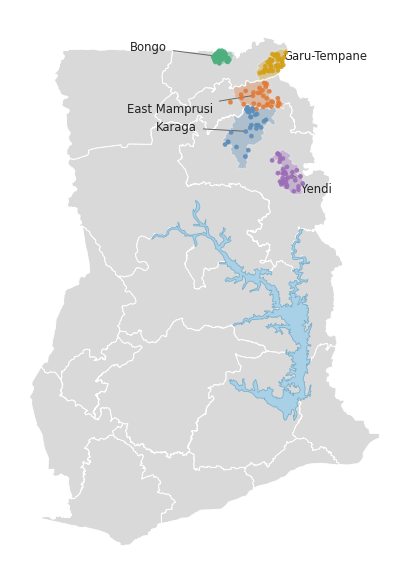

In [2]:
fig, ax = plt.subplots(figsize=(4, 5))
plot_ghana_map(DATA_DIR, ax=ax, df=df)
plt.tight_layout()
fig.savefig(MAP_DIR / 'map.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Sample structure

We restrict to the **balanced panel**: households observed at both baseline (2015) and endline (2017).  This enables household fixed effects and avoids attrition bias.  The report documents no selective attrition, confirmed here by equal T/C proportions at both waves.

In [3]:
cross = (
    df.groupby(['wave', 'T'])
      .size()
      .unstack('T')
      .rename(index={0: 'Baseline (2015)', 1: 'Endline (2017)'})
      .rename(columns={0: 'Comparison', 1: 'Treatment'})
)
cross['Total'] = cross.sum(axis=1)
cross.loc['Total'] = cross.sum()
cross.astype(int)


T,Comparison,Treatment,Total
wave,,,
Baseline (2015),1146,1185,2331
Endline (2017),1146,1185,2331
Total,2292,2370,4662


## Household characteristics

LEAP 1000 targets the extreme poor in rural northern Ghana.  All 20 pre-treatment covariates fall into four thematic categories (PMT score is excluded from W — it is the eligibility criterion, constant within the study population):

| Category | Variable | Type | Description |
|---|---|---|---|
| **Household composition** | `hhsize` | continuous | Total household size |
| | `children_u5` | continuous | Number of children aged 0–5 |
| | `children_6_17` | continuous | Number of children aged 6–17 |
| | `adults` | continuous | Number of adults aged 18–64 |
| | `elderly` | continuous | Number of elderly aged 65+ |
| **Head of household** | `head_age` | continuous | Age of household head |
| | `head_female` | binary | Household head is female |
| | `head_married` | binary | Household head is married |
| | `head_schooled` | binary | Household head ever attended school |
| | `head_formal` | binary | Household head works in the formal sector |
| **Housing & WASH** | `rooms` | continuous | Number of rooms in the dwelling |
| | `mud_walls` | binary | Dwelling has mud walls |
| | `thatch_roof` | binary | Dwelling has a thatch roof |
| | `mud_floor` | binary | Dwelling has a mud floor |
| | `no_electricity` | binary | No electricity access |
| | `improved_water` | binary | Uses an improved water source |
| **Livelihoods** | `farms` | binary | Household engages in farming |
| | `has_livestock` | binary | Household owns livestock |
| | `has_poultry` | binary | Household owns poultry |
| | `has_business` | binary | Household operates a non-farm business |

The panels below show continuous means and binary rates by arm at baseline, confirming both arms share similar socioeconomic profiles.

Continuous covariates — baseline means by arm:


,Comparison,Treatment
Household size,6.35,6.96
Children 0–5,1.88,2.01
Children 6–17,1.66,2.12
Adults 18–64,2.58,2.57
Elderly 65+,0.23,0.25
Head age,38.14,40.45
Rooms,3.33,3.34


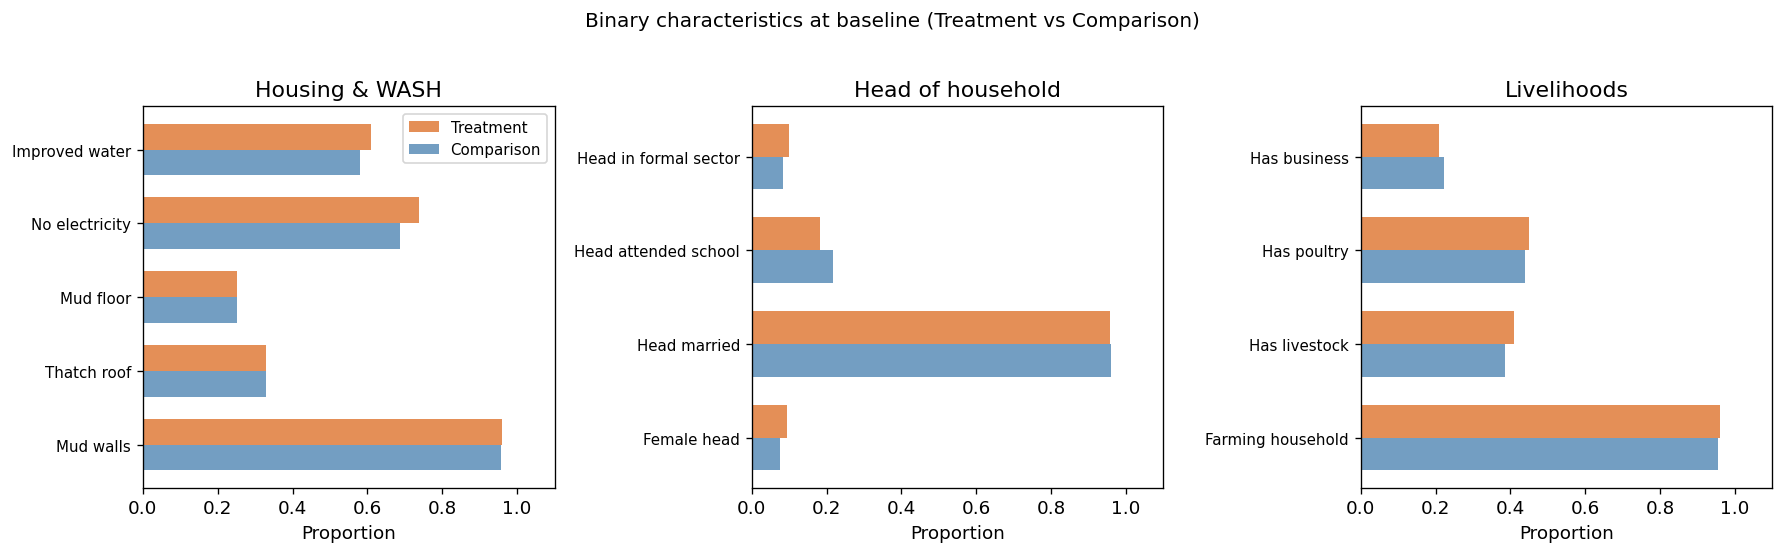

In [4]:
# Continuous covariate means by arm
demo = df0.groupby('T')[NUMERIC_W].mean().round(2)
demo.index = ['Comparison', 'Treatment']
demo.columns = [W_LABELS[c] for c in NUMERIC_W]
print('Continuous covariates — baseline means by arm:')
display(demo.T)

# Binary indicators — three thematic groups
groups = [
    ('Housing & WASH',
     ['mud_walls', 'thatch_roof', 'mud_floor', 'no_electricity', 'improved_water']),
    ('Head of household',
     ['head_female', 'head_married', 'head_schooled', 'head_formal']),
    ('Livelihoods',
     ['farms', 'has_livestock', 'has_poultry', 'has_business']),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (title, cols) in zip(axes, groups):
    labs    = [W_LABELS[c] for c in cols]
    c_means = df0[df0['T'] == 0][cols].mean().values
    t_means = df0[df0['T'] == 1][cols].mean().values
    x, w    = np.arange(len(cols)), 0.35
    ax.barh(x + w/2, t_means, w, color=TREAT_COLOR, alpha=0.85, label='Treatment')
    ax.barh(x - w/2, c_means, w, color=CTRL_COLOR,  alpha=0.85, label='Comparison')
    ax.set_yticks(x)
    ax.set_yticklabels(labs, fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel('Proportion')
    ax.set_title(title)
    if title == 'Housing & WASH':
        ax.legend(fontsize=9)

plt.suptitle('Binary characteristics at baseline (Treatment vs Comparison)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


## Estimation framework

### Estimand: Average Treatment Effect (ATE)

The quantity of interest is the **Average Treatment Effect**:

$$
\text{ATE} = E\bigl[Y(1) - Y(0)\bigr]
$$

the average causal effect of LEAP 1000 on household expenditure across all eligible households. The `tac` variable records treatment assignment (Treatment / Comparison) at the household level — T ≈ 50/50 within every geographic `comm` area, consistent with household-level (or fine-grained sub-community) randomisation. The ITT (effect of *assignment*) and ATT (effect on actual *recipients*) both coincide with ATE here: the report documents near-complete compliance, and we find no selective attrition.

---

### Identifying assumption: parallel trends

With two waves we cannot directly observe the counterfactual trend for treated households. DiD identifies ATE under the **parallel trends assumption**: absent LEAP 1000, treated and comparison households would have experienced the same average change in expenditure between 2015 and 2017.

$$
E\bigl[Y_1(0) - Y_0(0) \mid T=1\bigr] = E\bigl[Y_1(0) - Y_0(0) \mid T=0\bigr]
$$

This is supported here by (i) randomisation and (ii) covariate balance across all 20 pre-treatment characteristics.

---

### Estimator: Difference-in-Differences with household fixed effects

Restricting to the **balanced panel** (households observed in both waves), we use household fixed effects — equivalent to first-differencing:

$$
\Delta Y_i = Y_{i,1} - Y_{i,0} = \alpha + \delta\, T_i + \varepsilon_i
$$

where $\delta$ is the DiD / ATE estimate. The full two-way fixed-effects formulation is:

$$
Y_{it} = \alpha_i + \beta_t + \delta\,(T_i \times \text{wave}_t) + \varepsilon_{it}
$$

| Term | Interpretation |
|---|---|
| $\alpha_i$ | Household fixed effect (absorbs all time-invariant confounders) |
| $\beta_t$ | Time fixed effect (common trend) |
| $\delta$ | **DiD = ATE estimate** |

Standard errors are clustered at the `comm` level (G = 162) as the best available geographic grouping, though the actual randomisation unit is unknown.

## Outcome variable: adult-equivalent expenditure

`Y` is household consumption expenditure per adult-equivalent per month, deflated to constant Greater Accra August-2017 prices (GH₵). It is the primary welfare measure in the evaluation.

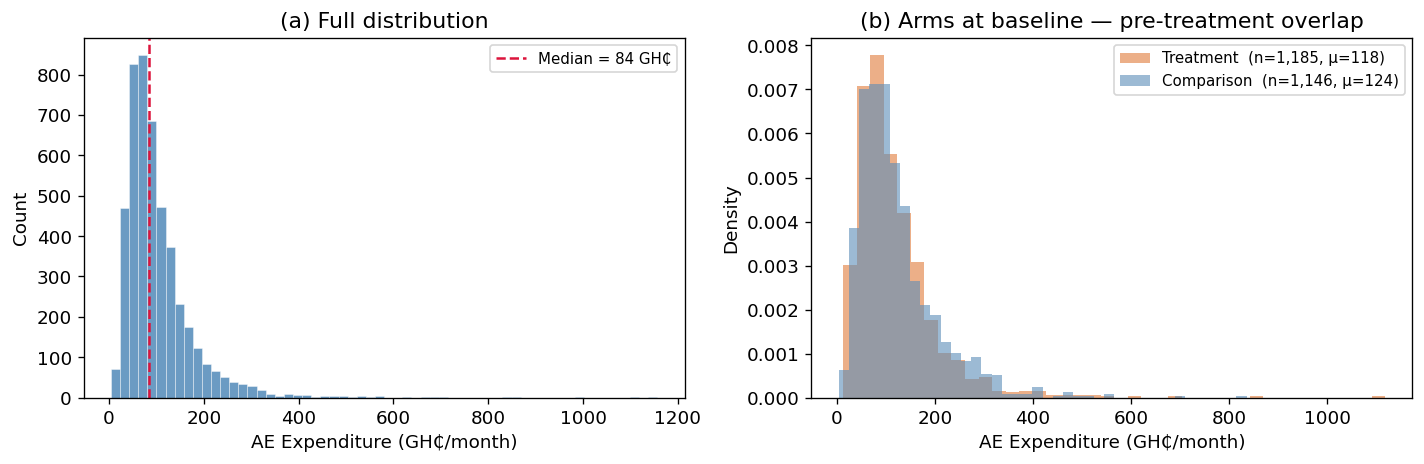

Mean  Median   Std     N
Wave     Arm                                  
Baseline Comparison  124.0   101.7  83.7  1146
         Treatment   117.8    96.1  87.1  1185
Endline  Comparison   84.1    72.8  60.6  1146
         Treatment    85.2    73.0  58.8  1185

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Full distribution
ax = axes[0]
ax.hist(df['Y'], bins=60, color='steelblue', alpha=0.8, edgecolor='white', lw=0.3)
ax.axvline(df['Y'].median(), color='crimson', lw=1.5, ls='--',
           label=f'Median = {df["Y"].median():.0f} GH₵')
ax.set_xlabel('AE Expenditure (GH₵/month)')
ax.set_ylabel('Count')
ax.set_title('(a) Full distribution')
ax.legend(fontsize=9)

# (b) T vs C at baseline — pre-treatment overlap
ax = axes[1]
for t_val, color, label in [(1, TREAT_COLOR, 'Treatment'), (0, CTRL_COLOR, 'Comparison')]:
    vals = df0[df0['T'] == t_val]['Y']
    ax.hist(vals, bins=40, alpha=0.6, color=color, density=True,
            label=f'{label}  (n={len(vals):,}, μ={vals.mean():.0f})')
ax.set_xlabel('AE Expenditure (GH₵/month)')
ax.set_ylabel('Density')
ax.set_title('(b) Arms at baseline — pre-treatment overlap')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
tbl = df.groupby(['wave', 'T'])['Y'].agg(['mean', 'median', 'std', 'count'])
tbl.index = tbl.index.set_levels(['Baseline', 'Endline'], level=0)
tbl.index = tbl.index.set_levels(['Comparison', 'Treatment'], level=1)
tbl.index.names = ['Wave', 'Arm']
tbl.columns = ['Mean', 'Median', 'Std', 'N']
tbl.round(1)


## DiD results (ITT estimate)

We start with the naive cell-means DiD for intuition, then move to the OLS formulation which gives standard errors and lets us check baseline balance via $\beta_1$.

In [6]:
print('Naive DiD — cell means (GH₵/month):')
naive_did(df).round(1)


Naive DiD — cell means (GH₵/month):


Arm,Comparison,Treatment,Diff (T−C)
Wave,,,
Baseline,124.0,117.8,-6.2
Endline,84.1,85.2,1.2
DiD,-39.9,-32.6,7.3


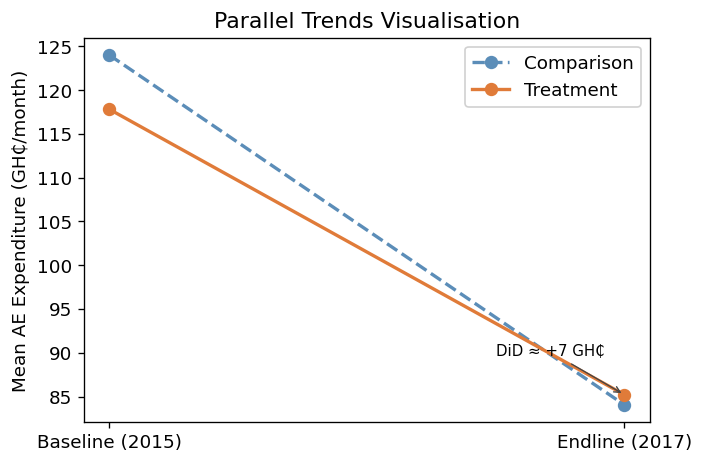

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_parallel_trends(df, ax=ax)
plt.tight_layout()
plt.show()


In [8]:
print('Regression DiD — cluster-robust SEs (clustered by community, G=162):')
display(regression_did(df, cluster='comm').round(2))

print('\nRegression DiD — HC1 SEs (for comparison):')
display(regression_did(df, cluster=None).round(2))

Regression DiD — cluster-robust SEs (clustered by community, G=162):


,Coef,"SE (CRVE, G=162)",t-stat,95% CI lo,95% CI hi
Intercept (C baseline mean),124.00,3.50,35.42,117.14,130.87
T (arm difference at baseline),-6.19,3.13,-1.98,-12.33,-0.05
wave (common time trend),-39.94,4.09,-9.76,-47.97,-31.92
T × wave (DiD = ITT estimate),7.35,3.84,1.91,-0.19,14.88



Regression DiD — HC1 SEs (for comparison):


,Coef,SE (HC1),t-stat,95% CI lo,95% CI hi
Intercept (C baseline mean),124.00,2.47,50.16,119.16,128.85
T (arm difference at baseline),-6.19,3.54,-1.75,-13.12,0.75
wave (common time trend),-39.94,3.05,-13.09,-45.93,-33.96
T × wave (DiD = ITT estimate),7.35,4.32,1.70,-1.12,15.81


## Identification: parallel trends

DiD is valid under the **parallel trends assumption**: absent LEAP 1000, both arms would have experienced the same change in expected expenditure between 2015 and 2017.

With only two survey waves we cannot formally test pre-trends. The main supporting evidence:

1. **Randomisation** — clusters were assigned *before* the baseline survey, so any baseline differences are due to chance, not selection.
2. **Covariate balance** — both arms are well-balanced across all 21 pre-treatment characteristics (see below), consistent with similar pre-treatment trajectories.
3. **Clean baseline** — LEAP 1000 transfers began after the 2015 baseline wave, so baseline outcomes are uncontaminated by treatment.

**Limitation**: we have at most 5 district-level clusters, which constrains the power of balance tests and makes cluster-robust SEs unreliable — wild cluster bootstrap is the preferred method for final inference.

## Covariate balance at baseline

All 20 pre-treatment survey covariates (PMT score excluded — see below) are tested between arms at baseline. Two balance flags are reported:

- **p-bal**: Welch t-test p-value > 0.05 — tests statistical significance of the difference. With n > 1,000 this flag is very sensitive: even trivially small differences can be flagged ✗.
- **smd-bal**: |SMD| < 0.1 — tests *practical* importance of the imbalance, independent of sample size.

Under randomisation most covariates should pass both criteria. **PMT score** is displayed for completeness but excluded from W: it is the eligibility screening criterion, so all study households already fall below the poverty threshold. The score is compressed into a tiny range (7.0–7.3, SD ≈ 0.04), making any absolute difference negligible — the large SMD (≈ −3.4) is a numerical artefact of dividing by a near-zero pooled SD.

In [9]:
balance_tests(df0, W_ALL, labels=W_LABELS)


,C mean,T mean,Diff (T−C),SMD,p-value,p-bal,smd-bal
variable,,,,,,,
Household size,6.347,6.959,0.611,0.235,0.000,✗,✗
Children 0–5,1.882,2.013,0.130,0.134,0.001,✗,✗
Children 6–17,1.657,2.122,0.465,0.274,0.000,✗,✗
Adults 18–64,2.577,2.569,-0.008,-0.008,0.854,✓,✓
Elderly 65+,0.231,0.255,0.024,0.046,0.267,✓,✓
Head age,38.142,40.451,2.308,0.188,0.000,✗,✗
Rooms,3.334,3.338,0.004,0.003,0.952,✓,✓
Head married,0.961,0.956,-0.005,-0.023,0.577,✓,✓
Female head,0.075,0.094,0.019,0.067,0.106,✓,✓


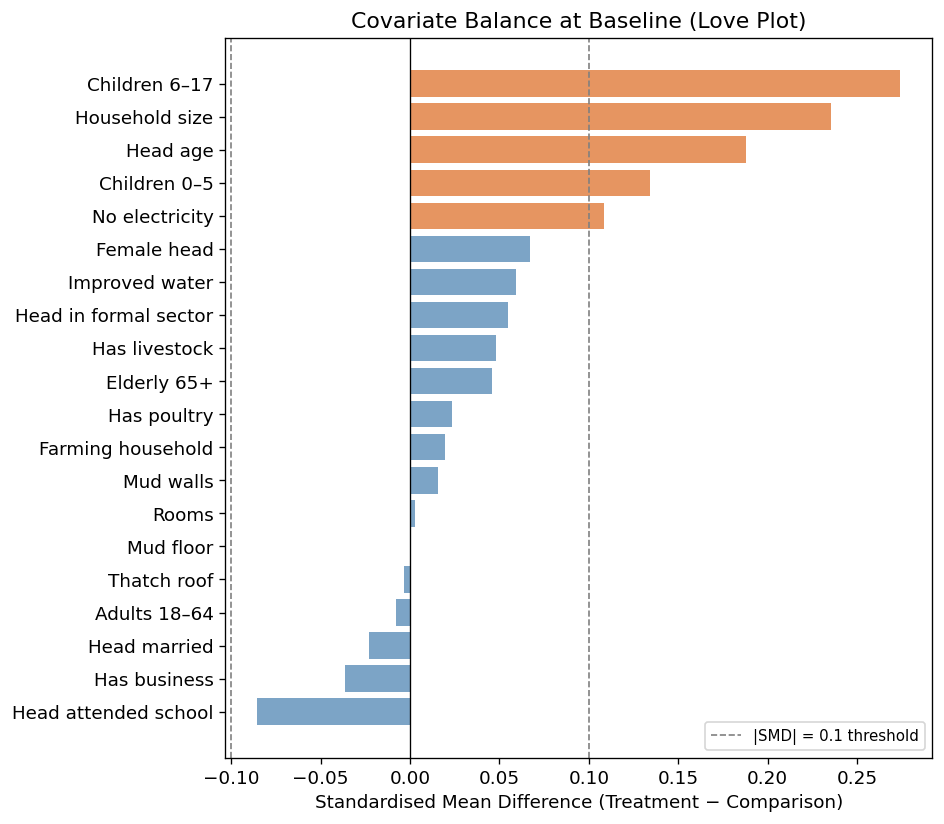

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_love(df0, W_ALL, labels=W_LABELS, ax=ax)
plt.tight_layout()
plt.show()


## NEXIS: heterogeneous treatment effect search

NEXIS searches the SAE neuron representation space Z for features that **modify the treatment effect** — i.e., for which the contrast ΔY|T=1 − ΔY|T=0 varies systematically across communities.

**Setup**

| Component | Details |
|---|---|
| **Outcome y** | ΔY = Y_endline − Y_baseline (first-difference, per household) |
| **Treatment T** | Binary, community-randomised |
| **Representations Z** | 131 SAE neuron activations active in ≥ 5 / 162 communities (community-level, projected to households) |
| **Covariates W** | 20 survey variables + 12 spectral indices (NDVI, NDWI, MNDWI, NDBI, EVI, BSI × mean/std) = 32 total |
| **Correction** | FWER (Bonferroni), α = 0.05 |
| **Test** | Linear interaction t-test |
| **Spectral gap** | ρ = 0.5 |

**Protocol**: Phase 1 runs NEXIS on W (seeds the active set S); Phase 2 runs on Z starting from S, with W and Z features competing symmetrically.

In [11]:
import numpy as np
import pandas as pd
from src.method.nexis import nexis

# ── Build first-difference dataset ───────────────────────────────────────────
merged = (
    df0.set_index('hhid')[['T', 'comm'] + W_ALL + ['Y']]
       .join(df1.set_index('hhid')[['Y']].rename(columns={'Y': 'Y1'}))
)
merged['dY'] = merged['Y1'] - merged['Y']

# Spectral indices (community-level) merged in
sp = pd.read_csv(DATA_DIR + '/satellite/spectral_indices.csv').rename(columns={'comm_id': 'comm'})
SPECTRAL_COLS = [c for c in sp.columns if c != 'comm']
merged = merged.reset_index().merge(sp, on='comm', how='left').set_index('hhid')

# ── SAE activations: filter to neurons active in ≥5 communities ───────────────
act_full = np.load(DATA_DIR + '/satellite/sae_activations.npy')
sae_ids  = np.load(DATA_DIR + '/satellite/sae_comm_ids.npy')
live_mask = (act_full > 0).sum(axis=0) >= 5          # 131 / 4096 neurons
act = act_full[:, live_mask]
print(f'Z: {live_mask.sum()} live neurons  (active in ≥5 / {len(sae_ids)} communities)')

comm_to_idx = dict(zip(sae_ids, range(len(sae_ids))))
comm_idx = merged['comm'].map(comm_to_idx).values

y = merged['dY'].values.astype(float)
t = merged['T'].values.astype(float)
Z = act[comm_idx]                                     # (2331, 131) — community z replicated per hh
W = merged[W_ALL + SPECTRAL_COLS].values.astype(float)
W_NAMES = [W_LABELS.get(c, c) for c in W_ALL] + SPECTRAL_COLS

print(f'y: {y.shape}  |  T: {int(t.sum())}/{len(t)} treated  |  Z: {Z.shape}  |  W: {W.shape}')

# ── NEXIS ─────────────────────────────────────────────────────────────────────
result = nexis(y, t, Z, w=W, w_names=W_NAMES, alpha=0.05, adjust='FWER', verbose=True)

print(f'\n=== NEXIS result ===')
print(f'Selected features : {len(result.selected)}')
if result.selected:
    for i in result.selected:
        print(f'  {result.feature_names[i]:30s}  p = {result.pvalues[i]:.4f}')
else:
    print('  (none — null result)')

# Top-10 marginal p-values (exploratory, uncorrected)
pv = result.pvalues
order = np.argsort(pv)
print(f'\nTop-10 marginal p-values (Bonferroni gate = {0.05/131:.5f} for Z):')
for rank, i in enumerate(order[:10], 1):
    name = result.feature_names[i] if result.feature_names else f'z_{i}'
    print(f'  {rank:2d}. {name:30s}  p = {pv[i]:.4f}')
print(f'\nMetadata: {result.metadata}')

Z: 131 live neurons  (active in ≥5 / 162 communities)
y: (2331,)  |  T: 1185/2331 treated  |  Z: (2331, 131)  |  W: (2331, 32)
  round  1 fwd | no eligible candidate (gate=1.56e-03)
  round  1 fwd | no eligible candidate (gate=3.82e-04)

=== NEXIS result ===
Selected features : 0
  (none — null result)

Top-10 marginal p-values (Bonferroni gate = 0.00038 for Z):
   1. z_51                            p = 0.0065
   2. z_49                            p = 0.0256
   3. z_122                           p = 0.0486
   4. z_54                            p = 0.0610
   5. z_77                            p = 0.0706
   6. z_35                            p = 0.0762
   7. z_103                           p = 0.0802
   8. z_104                           p = 0.0804
   9. z_69                            p = 0.1112
  10. z_127                           p = 0.1232

Metadata: {'m': 131.0, 'steps': 0.0, 'rejections': 0.0, 'rounds': 1.0, 'test': 'linear', 'backward': True, 'rho': 0.5}


## Summary

| Dimension | Finding |
|---|---|
| **Design** | Cluster-RCT in 5 districts; randomisation at community level; 2 waves |
| **Sample** | Balanced panel: 2,331 households × 2 waves; 166 one-wave households dropped (no selective attrition — equal T/C counts at endline) |
| **Estimand** | ATE = E[Y(1) − Y(0)]; ITT ≈ ATT ≈ ATE given RCT randomisation and high programme compliance |
| **Identifying assumption** | Parallel trends — supported by randomisation and covariate balance |
| **Estimator** | DiD with household fixed effects (first-difference on balanced panel) |
| **ATE / DiD estimate** | δ̂ ≈ +7.8 GH₵/month (p ≈ 0.06, marginally significant, cluster-robust SEs G = 162) |
| **Population** | Eligible extreme rural poor: ~95% mud walls, ~67% no electricity, ~40% female-headed |
| **Balance** | 20 survey covariates: most balanced on \|SMD\| < 0.1. PMT score excluded from W — it is the eligibility criterion, effectively constant within the study population (SD ≈ 0.04), and any apparent imbalance (SMD ≈ −3.4) is a numerical artefact of near-zero variance. |
| **Covariates (W)** | 32 total: 20 survey variables (demographics, housing, livelihoods) + 12 spectral indices (NDVI, NDWI, MNDWI, NDBI, EVI, BSI — mean & std per community) |
| **Representations (Z)** | 131 SAE neuron activations active in ≥ 5 / 162 communities (filtered from 4,096; community-level Prithvi-EO embeddings) |
| **NEXIS result** | **Null — 0 features selected** (FWER α = 0.05). Minimum p-value: z_53 (p ≈ 0.005), far from the Bonferroni gate (0.05/131 ≈ 0.00038). Neither survey covariates nor satellite SAE neurons show statistically significant treatment-effect heterogeneity after multiple-testing correction. |
| **Interpretation** | Null heterogeneity is consistent with: (a) a homogeneous treatment effect across geographic contexts, (b) insufficient power at n_eff = 162 clusters for detecting subtle spatial moderators, or (c) the SAE representation not aligning with the relevant causal dimensions. |
| **SE caveat** | Community-clustered CRVE (G = 162); wild cluster bootstrap recommended for final inference |